# FER Experiments
### Datasets
- FER2013
- CK+
- AffectNet
- RF-DB

In [1]:
import random
import tensorflow as tf
import numpy as np

SEED = 8

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)


In [2]:
import os, sys
module_path = os.path.abspath(os.path.join('..', '..')) 
sys.path.insert(0, module_path)
from src.data_loading import load_rafbd, load_ck, load_fer2013, load_affectnet, load_meld, filter_emotions, load_iemocap
from src.evaluation import plot_confusion_matrix, plot_training_history
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from keras.models import load_model
from PIL import Image
import cv2


def split_dataset_train_val_test(df, val_size=0.2, test_size=0.3, seed=SEED):
    train_val_df, test_df = train_test_split(df, test_size=test_size, random_state=seed, stratify=df['label'])
    train_df, val_df = train_test_split(train_val_df, test_size=val_size/(1 - test_size), random_state=seed, stratify=train_val_df['label'])
    return train_df, val_df, test_df

def preprocess_fer_row(pixels_str, target_size=(48, 48)):
    # Convert string of space-separated pixel values to 2D image
    pixels = np.fromstring(pixels_str, sep=' ', dtype=np.uint8)
    pixels = pixels.reshape(target_size)
    # Convert to float, normalize, and expand dims
    pixels = pixels.astype("float32") / 255.0
    pixels = np.expand_dims(pixels, axis=-1)
    return pixels

def preprocess_raf_row(filename):
    # read and convert image to grayscale
    image = Image.open(filename).convert('L')
    image = image.resize((48, 48))
    np_image = np.array(image).astype("float32") / 255.0
    np_image = np.expand_dims(np_image, axis=-1)
    return np_image


ck = filter_emotions(load_ck())
fer = filter_emotions(load_fer2013())
raf = filter_emotions(load_rafbd())
affect = filter_emotions(load_affectnet())

ck["pixels"] = ck["pixels"].apply(preprocess_fer_row)
fer["pixels"] = fer["pixels"].apply(preprocess_fer_row)
raf["pixels"] = raf["filename"].apply(preprocess_raf_row)
affect["pixels"] = affect["filename"].apply(preprocess_raf_row)


ck_train, ck_val, ck_test = split_dataset_train_val_test(ck)
raf_train, raf_val, raf_test = split_dataset_train_val_test(raf)
affect_train, affect_val, affect_test = split_dataset_train_val_test(affect)
fer_train, fer_val, fer_test = split_dataset_train_val_test(fer)

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Subfolders in the dataset: ['ckextended.csv']
Subfolders in the dataset: ['fer2013.csv']


100%|██████████| 3068/3068 [00:00<00:00, 5478.95it/s]


Dataset downloaded to: /Users/krazmic/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1
Available folders: ['happy', 'Contempt', 'sad', 'fear', 'surprise', 'neutral', 'Anger', 'disgust']


100%|██████████| 8/8 [00:06<00:00,  1.28it/s]


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from fer_cnn_utils import preprocess_frame, build_light_cnn
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)


def build_light_cnn(input_shape=(48, 48, 1), num_classes=7):
    """
    Lightweight CNN for emotion recognition from frames.
    """
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(256, (3,3), activation='relu', padding='same',),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dropout(0.7),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving
    ReduceLROnPlateau(
        #monitor="val_loss",
        monitor="val_accuracy",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# FER2013

2026-01-19 11:10:07.357812: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-01-19 11:10:07.358013: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-19 11:10:07.358017: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-01-19 11:10:07.358344: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-19 11:10:07.358742: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/100


2026-01-19 11:10:08.995812: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


561/561 [==============================] - ETA: 0s - loss: 3.9618 - accuracy: 0.2234
Epoch 1: val_accuracy improved from -inf to 0.29716, saving model to best_cnn_model.h5
561/561 [==============================] - 15s 24ms/step - loss: 3.9618 - accuracy: 0.2234 - val_loss: 1.9742 - val_accuracy: 0.2972 - lr: 0.0010
Epoch 2/100
  4/561 [..............................] - ETA: 10s - loss: 3.7158 - accuracy: 0.2266

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


559/561 [============================>.] - ETA: 0s - loss: 3.0234 - accuracy: 0.3029
Epoch 2: val_accuracy improved from 0.29716 to 0.39161, saving model to best_cnn_model.h5
561/561 [==============================] - 11s 19ms/step - loss: 3.0229 - accuracy: 0.3031 - val_loss: 2.1214 - val_accuracy: 0.3916 - lr: 0.0010
Epoch 3/100
561/561 [==============================] - ETA: 0s - loss: 2.4361 - accuracy: 0.3598
Epoch 3: val_accuracy did not improve from 0.39161
561/561 [==============================] - 11s 20ms/step - loss: 2.4361 - accuracy: 0.3598 - val_loss: 1.7755 - val_accuracy: 0.3749 - lr: 0.0010
Epoch 4/100
559/561 [============================>.] - ETA: 0s - loss: 2.0827 - accuracy: 0.3934
Epoch 4: val_accuracy improved from 0.39161 to 0.39955, saving model to best_cnn_model.h5
561/561 [==============================] - 11s 20ms/step - loss: 2.0823 - accuracy: 0.3934 - val_loss: 1.7967 - val_accuracy: 0.3996 - lr: 0.0010
Epoch 5/100
558/561 [============================>.]

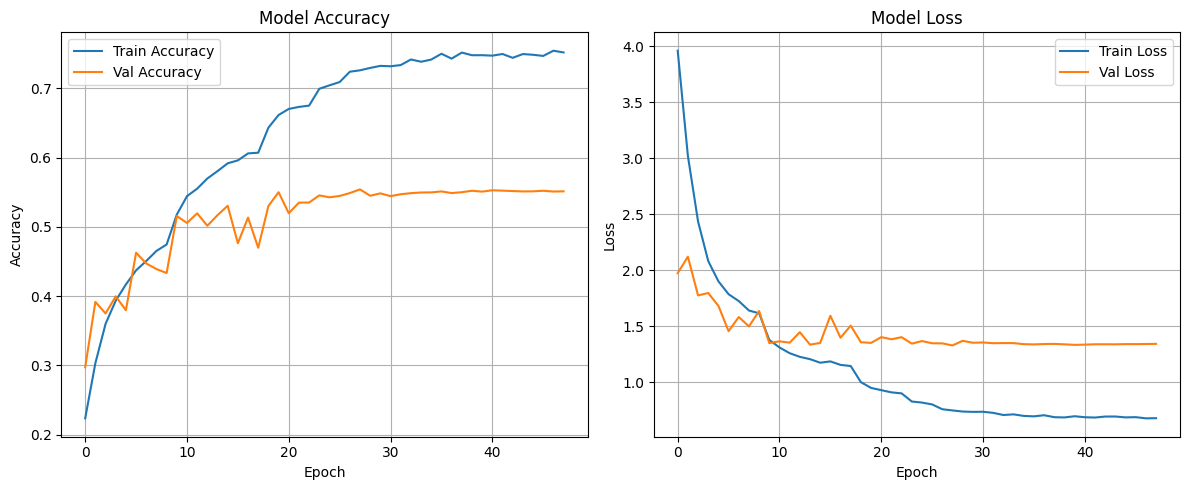

In [4]:

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(fer['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(fer_train["pixels"].values)
X_val   = np.stack(fer_val["pixels"].values)
X_test  = np.stack(fer_test["pixels"].values)

y_train = label_encoder.transform(fer_train['label'].values)
y_val = label_encoder.transform(fer_val['label'].values)
y_test = label_encoder.transform(fer_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

337/337 [==============================] - 2s 4ms/step
              precision    recall  f1-score   support

       angry       0.42      0.44      0.43      1486
     disgust       0.83      0.15      0.25       164
        fear       0.44      0.31      0.36      1536
       happy       0.78      0.76      0.77      2697
     neutral       0.45      0.56      0.50      1860
         sad       0.42      0.45      0.43      1823
    surprise       0.74      0.72      0.73      1201

    accuracy                           0.55     10767
   macro avg       0.58      0.48      0.49     10767
weighted avg       0.56      0.55      0.55     10767



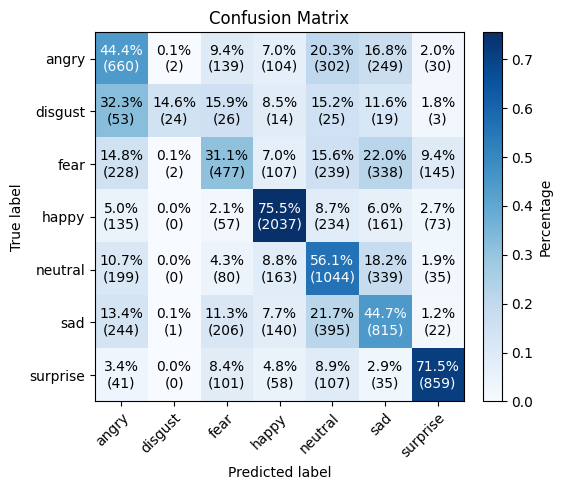

In [5]:

cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

29/29 [==============================] - 1s 20ms/step
              precision    recall  f1-score   support

       angry       0.26      0.44      0.33        45
     disgust       0.33      0.02      0.03        59
        fear       0.19      0.12      0.15        25
       happy       0.86      1.00      0.93        69
     neutral       0.89      0.93      0.91       593
         sad       0.15      0.14      0.15        28
    surprise       0.89      0.88      0.88        83

    accuracy                           0.80       902
   macro avg       0.51      0.50      0.48       902
weighted avg       0.78      0.80      0.78       902



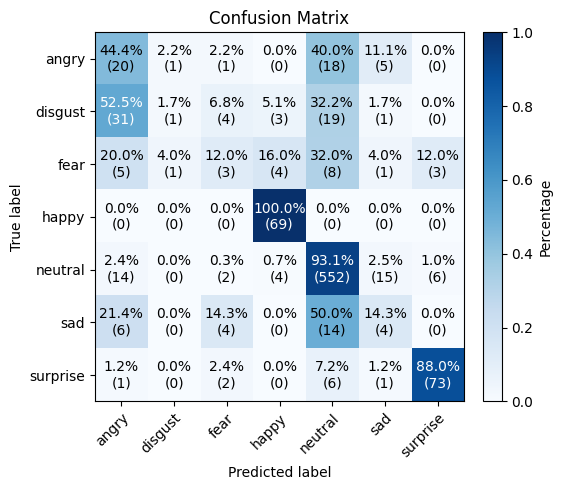

In [6]:
X_test = np.stack(ck["pixels"].values)
y_test = label_encoder.transform(ck['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

96/96 [==============================] - 1s 6ms/step
              precision    recall  f1-score   support

       angry       0.26      0.51      0.34       162
     disgust       0.00      0.00      0.00       160
        fear       0.10      0.20      0.14        74
       happy       0.78      0.77      0.77      1185
     neutral       0.49      0.59      0.54       680
         sad       0.35      0.40      0.37       478
    surprise       0.83      0.17      0.29       329

    accuracy                           0.54      3068
   macro avg       0.40      0.38      0.35      3068
weighted avg       0.57      0.54      0.53      3068



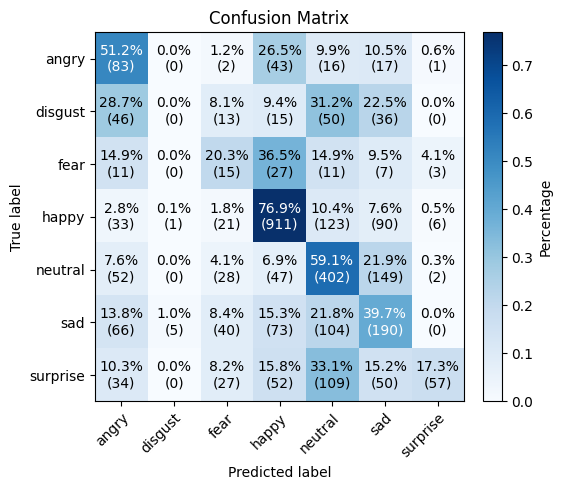

In [7]:
X_test = np.stack(raf["pixels"].values)
y_test = label_encoder.transform(raf['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

413/413 [==============================] - 2s 4ms/step
              precision    recall  f1-score   support

       angry       0.27      0.33      0.29      1718
     disgust       0.33      0.00      0.00      1248
        fear       0.34      0.15      0.21      1664
       happy       0.58      0.58      0.58      2704
     neutral       0.21      0.38      0.27      2368
         sad       0.15      0.27      0.19      1584
    surprise       0.47      0.14      0.22      1920

    accuracy                           0.30     13206
   macro avg       0.33      0.26      0.25     13206
weighted avg       0.35      0.30      0.29     13206



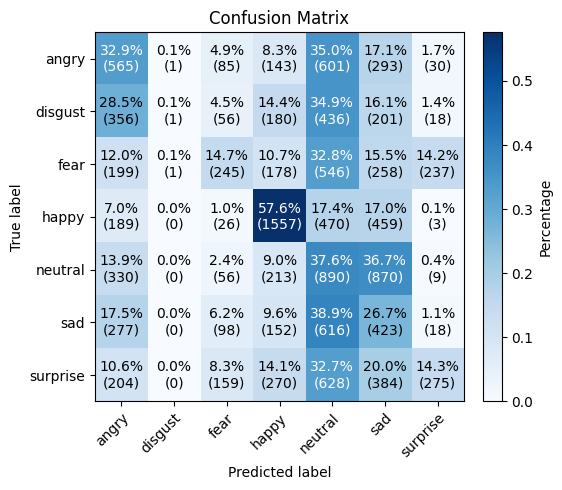

In [8]:
X_test = np.stack(affect["pixels"].values)
y_test = label_encoder.transform(affect['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### CK

Epoch 1/100
29/29 [==============================] - ETA: 0s - loss: 5.7085 - accuracy: 0.4822
Epoch 1: val_accuracy did not improve from 0.55405
29/29 [==============================] - 6s 127ms/step - loss: 5.7085 - accuracy: 0.4822 - val_loss: 2.3795 - val_accuracy: 0.0276 - lr: 0.0010
Epoch 2/100
28/29 [===========================>..] - ETA: 0s - loss: 3.9249 - accuracy: 0.5513
Epoch 2: val_accuracy improved from 0.55405 to 0.61326, saving model to best_cnn_model.h5
29/29 [==============================] - 1s 23ms/step - loss: 3.9161 - accuracy: 0.5511 - val_loss: 1.7961 - val_accuracy: 0.6133 - lr: 0.0010
Epoch 3/100
 6/29 [=====>........................] - ETA: 0s - loss: 3.3157 - accuracy: 0.5417

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


28/29 [===========================>..] - ETA: 0s - loss: 2.7254 - accuracy: 0.5603
Epoch 3: val_accuracy improved from 0.61326 to 0.65746, saving model to best_cnn_model.h5
29/29 [==============================] - 1s 21ms/step - loss: 2.7471 - accuracy: 0.5600 - val_loss: 1.5557 - val_accuracy: 0.6575 - lr: 0.0010
Epoch 4/100
25/29 [========================>.....] - ETA: 0s - loss: 2.1463 - accuracy: 0.5950
Epoch 4: val_accuracy did not improve from 0.65746
29/29 [==============================] - 1s 18ms/step - loss: 2.1202 - accuracy: 0.5933 - val_loss: 1.8847 - val_accuracy: 0.6575 - lr: 0.0010
Epoch 5/100
29/29 [==============================] - ETA: 0s - loss: 1.8531 - accuracy: 0.6578
Epoch 5: val_accuracy did not improve from 0.65746
29/29 [==============================] - 1s 18ms/step - loss: 1.8531 - accuracy: 0.6578 - val_loss: 2.2843 - val_accuracy: 0.6575 - lr: 0.0010
Epoch 6/100
28/29 [===========================>..] - ETA: 0s - loss: 1.5848 - accuracy: 0.6875
Epoch 6: va

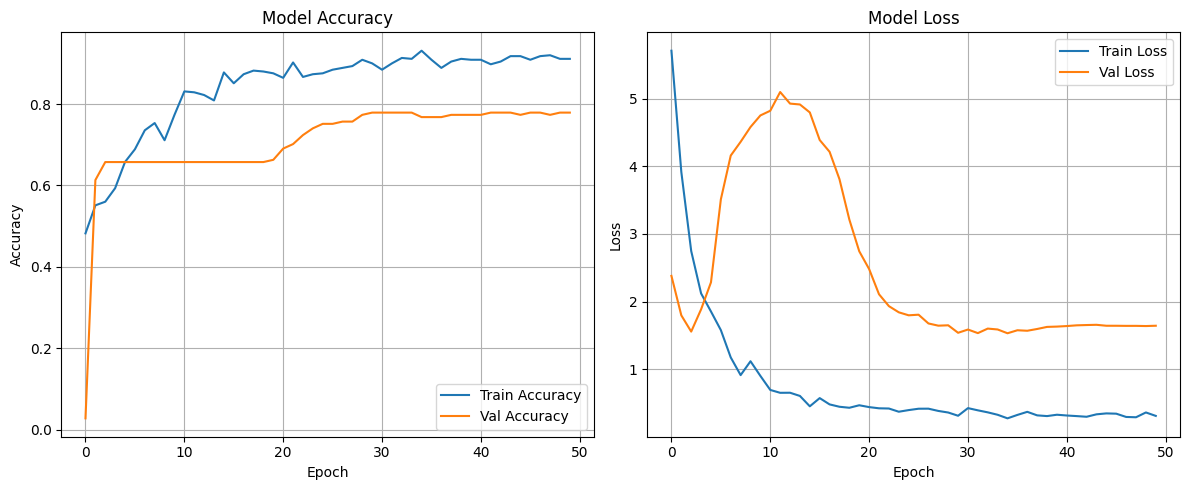

In [9]:

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(ck['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(ck_train["pixels"].values)
X_val   = np.stack(ck_val["pixels"].values)
X_test  = np.stack(ck_test["pixels"].values)

y_train = label_encoder.transform(ck_train['label'].values)
y_val = label_encoder.transform(ck_val['label'].values)
y_test = label_encoder.transform(ck_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

9/9 [==============================] - 0s 7ms/step
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00        14
     disgust       0.67      0.11      0.19        18
        fear       0.00      0.00      0.00         7
       happy       1.00      0.38      0.55        21
     neutral       0.74      0.99      0.85       178
         sad       0.00      0.00      0.00         8
    surprise       0.91      0.80      0.85        25

    accuracy                           0.76       271
   macro avg       0.47      0.33      0.35       271
weighted avg       0.69      0.76      0.69       271



/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

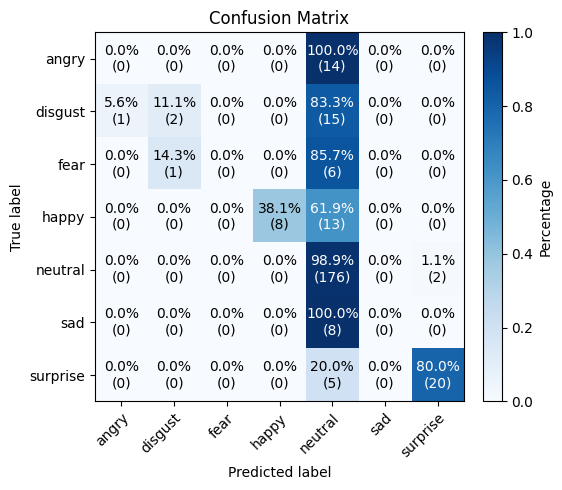

In [10]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

1122/1122 [==============================] - 5s 4ms/step
              precision    recall  f1-score   support

       angry       0.13      0.05      0.08      4953
     disgust       0.03      0.04      0.04       547
        fear       0.29      0.00      0.00      5121
       happy       0.38      0.08      0.13      8989
     neutral       0.19      0.85      0.32      6198
         sad       0.16      0.01      0.02      6077
    surprise       0.21      0.20      0.20      4002

    accuracy                           0.20     35887
   macro avg       0.20      0.18      0.11     35887
weighted avg       0.24      0.20      0.13     35887



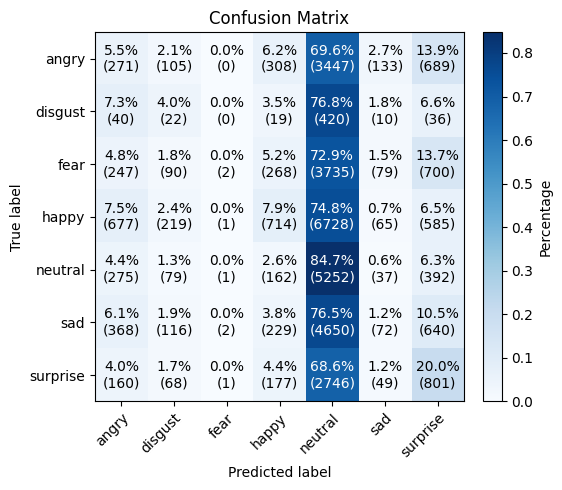

In [11]:
X_test = np.stack(fer["pixels"].values)
y_test = label_encoder.transform(fer['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

96/96 [==============================] - 0s 4ms/step
              precision    recall  f1-score   support

       angry       0.07      0.11      0.09       162
     disgust       0.11      0.04      0.06       160
        fear       1.00      0.01      0.03        74
       happy       0.42      0.03      0.05      1185
     neutral       0.24      0.91      0.38       680
         sad       0.35      0.01      0.03       478
    surprise       0.19      0.05      0.08       329

    accuracy                           0.23      3068
   macro avg       0.34      0.17      0.10      3068
weighted avg       0.33      0.23      0.13      3068



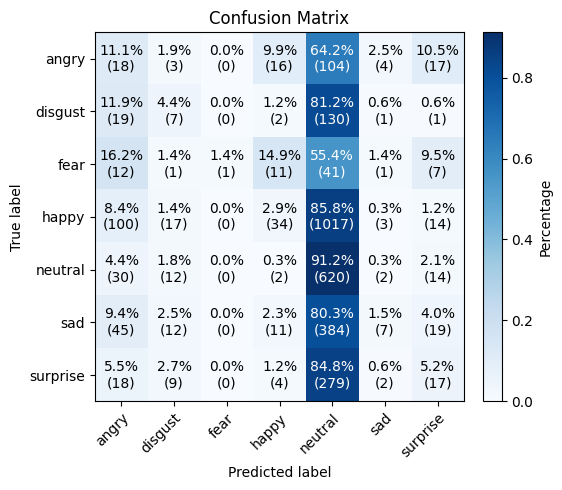

In [12]:
X_test = np.stack(raf["pixels"].values)
y_test = label_encoder.transform(raf['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

413/413 [==============================] - 2s 4ms/step
              precision    recall  f1-score   support

       angry       0.15      0.03      0.05      1718
     disgust       0.10      0.02      0.04      1248
        fear       0.00      0.00      0.00      1664
       happy       0.30      0.10      0.15      2704
     neutral       0.18      0.67      0.28      2368
         sad       0.10      0.01      0.02      1584
    surprise       0.17      0.22      0.19      1920

    accuracy                           0.18     13206
   macro avg       0.14      0.15      0.10     13206
weighted avg       0.16      0.18      0.12     13206



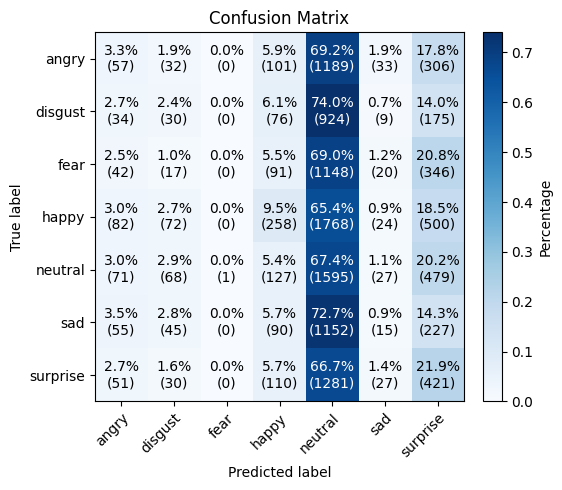

In [13]:
X_test = np.stack(affect["pixels"].values)
y_test = label_encoder.transform(affect['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### RAF-DB

Epoch 1/100
96/96 [==============================] - ETA: 0s - loss: 5.3457 - accuracy: 0.2981
Epoch 1: val_accuracy did not improve from 0.77901
96/96 [==============================] - 4s 39ms/step - loss: 5.3457 - accuracy: 0.2981 - val_loss: 2.1298 - val_accuracy: 0.3860 - lr: 0.0010
Epoch 2/100
95/96 [============================>.] - ETA: 0s - loss: 3.5979 - accuracy: 0.3507
Epoch 2: val_accuracy did not improve from 0.77901
96/96 [==============================] - 2s 17ms/step - loss: 3.6005 - accuracy: 0.3503 - val_loss: 2.2685 - val_accuracy: 0.3811 - lr: 0.0010
Epoch 3/100
96/96 [==============================] - ETA: 0s - loss: 3.3157 - accuracy: 0.3536
Epoch 3: val_accuracy did not improve from 0.77901
96/96 [==============================] - 2s 18ms/step - loss: 3.3157 - accuracy: 0.3536 - val_loss: 2.7892 - val_accuracy: 0.3893 - lr: 0.0010
Epoch 4/100
93/96 [============================>.] - ETA: 0s - loss: 2.9598 - accuracy: 0.3515
Epoch 4: val_accuracy did not improve 

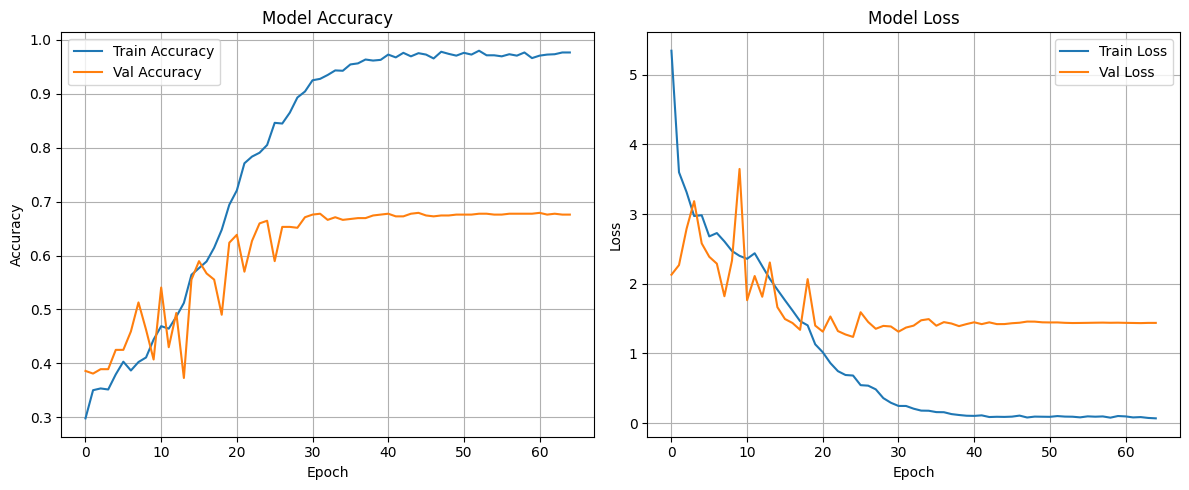

In [14]:

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(raf['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(raf_train["pixels"].values)
X_val   = np.stack(raf_val["pixels"].values)
X_test  = np.stack(raf_test["pixels"].values)

y_train = label_encoder.transform(raf_train['label'].values)
y_val = label_encoder.transform(raf_val['label'].values)
y_test = label_encoder.transform(raf_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

29/29 [==============================] - 0s 6ms/step
              precision    recall  f1-score   support

       angry       0.07      0.10      0.09        49
     disgust       0.12      0.04      0.06        48
        fear       1.00      0.05      0.09        22
       happy       0.36      0.02      0.04       356
     neutral       0.24      0.91      0.37       204
         sad       0.50      0.01      0.03       143
    surprise       0.29      0.07      0.11        99

    accuracy                           0.23       921
   macro avg       0.37      0.17      0.11       921
weighted avg       0.34      0.23      0.13       921



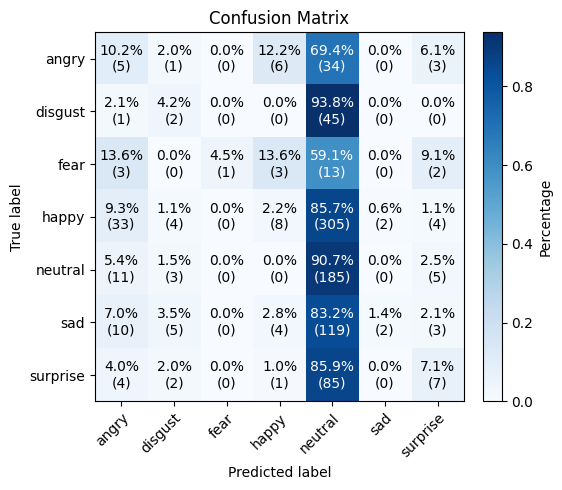

In [15]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

1122/1122 [==============================] - 4s 4ms/step
              precision    recall  f1-score   support

       angry       0.13      0.05      0.08      4953
     disgust       0.03      0.04      0.04       547
        fear       0.29      0.00      0.00      5121
       happy       0.38      0.08      0.13      8989
     neutral       0.19      0.85      0.32      6198
         sad       0.16      0.01      0.02      6077
    surprise       0.21      0.20      0.20      4002

    accuracy                           0.20     35887
   macro avg       0.20      0.18      0.11     35887
weighted avg       0.24      0.20      0.13     35887



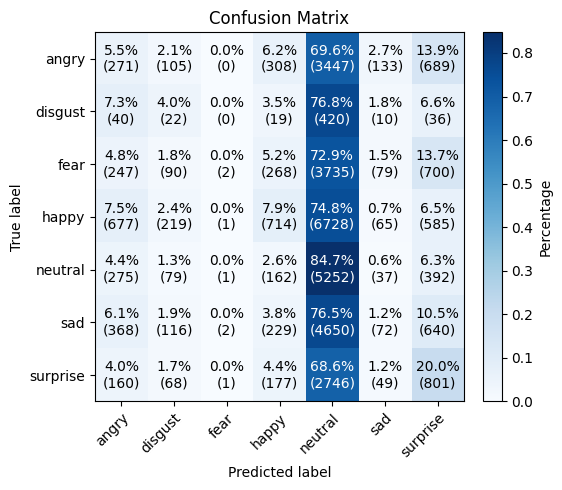

In [16]:
X_test = np.stack(fer["pixels"].values)
y_test = label_encoder.transform(fer['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

29/29 [==============================] - 0s 5ms/step
              precision    recall  f1-score   support

       angry       0.83      0.11      0.20        45
     disgust       0.93      0.24      0.38        59
        fear       1.00      0.04      0.08        25
       happy       0.98      0.67      0.79        69
     neutral       0.78      1.00      0.88       593
         sad       0.67      0.07      0.13        28
    surprise       0.96      0.89      0.93        83

    accuracy                           0.81       902
   macro avg       0.88      0.43      0.48       902
weighted avg       0.83      0.81      0.76       902



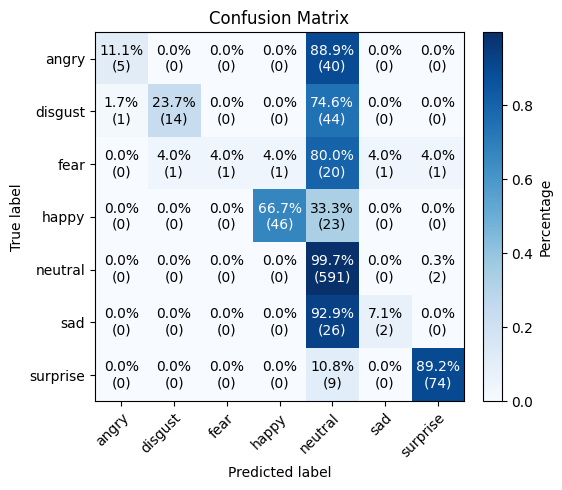

In [17]:
X_test = np.stack(ck["pixels"].values)
y_test = label_encoder.transform(ck['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

413/413 [==============================] - 2s 4ms/step
              precision    recall  f1-score   support

       angry       0.15      0.03      0.05      1718
     disgust       0.10      0.02      0.04      1248
        fear       0.00      0.00      0.00      1664
       happy       0.30      0.10      0.15      2704
     neutral       0.18      0.67      0.28      2368
         sad       0.10      0.01      0.02      1584
    surprise       0.17      0.22      0.19      1920

    accuracy                           0.18     13206
   macro avg       0.14      0.15      0.10     13206
weighted avg       0.16      0.18      0.12     13206



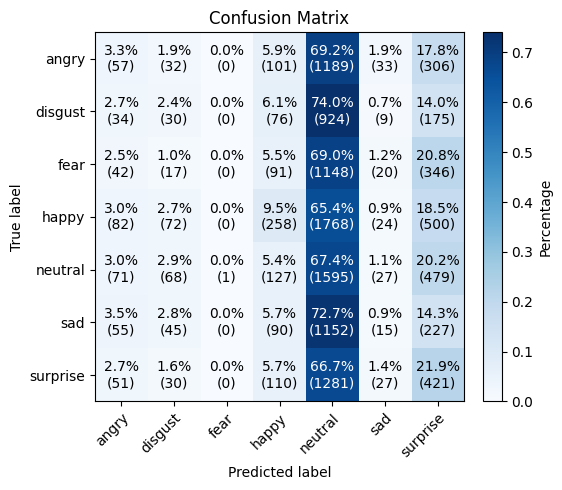

In [18]:
X_test = np.stack(affect["pixels"].values)
y_test = label_encoder.transform(affect['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### AffectNet

Epoch 1/100
207/207 [==============================] - ETA: 0s - loss: 4.9110 - accuracy: 0.2219
Epoch 1: val_accuracy did not improve from 0.77901
207/207 [==============================] - 7s 30ms/step - loss: 4.9110 - accuracy: 0.2219 - val_loss: 3.5133 - val_accuracy: 0.1200 - lr: 0.0010
Epoch 2/100
206/207 [============================>.] - ETA: 0s - loss: 3.3170 - accuracy: 0.2805
Epoch 2: val_accuracy did not improve from 0.77901
207/207 [==============================] - 4s 21ms/step - loss: 3.3181 - accuracy: 0.2805 - val_loss: 1.8809 - val_accuracy: 0.3452 - lr: 0.0010
Epoch 3/100
205/207 [============================>.] - ETA: 0s - loss: 2.7438 - accuracy: 0.3680
Epoch 3: val_accuracy did not improve from 0.77901
207/207 [==============================] - 4s 20ms/step - loss: 2.7467 - accuracy: 0.3676 - val_loss: 1.9256 - val_accuracy: 0.3736 - lr: 0.0010
Epoch 4/100
205/207 [============================>.] - ETA: 0s - loss: 2.4369 - accuracy: 0.4201
Epoch 4: val_accuracy di

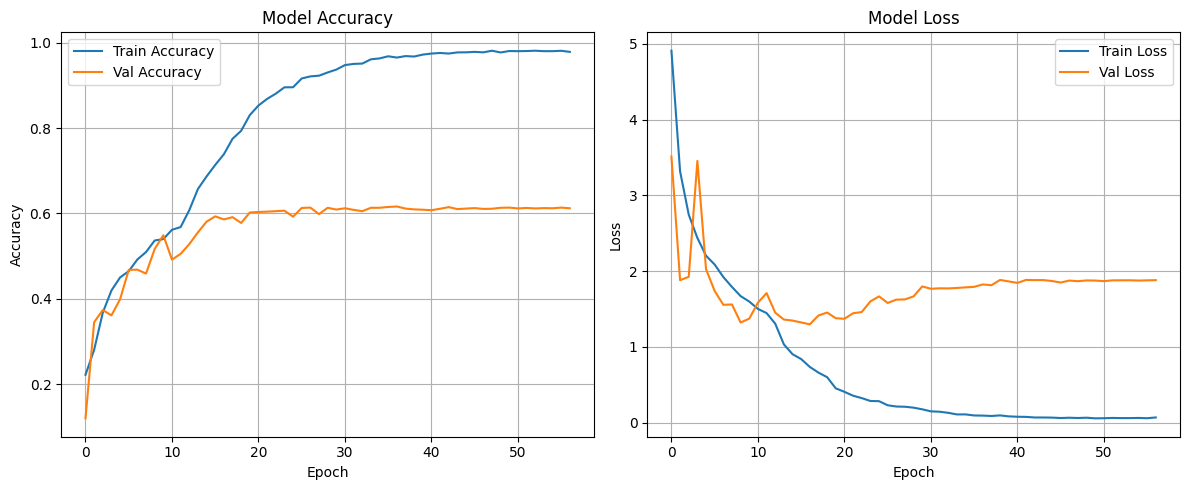

In [19]:

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(affect['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(affect_train["pixels"].values)
X_val   = np.stack(affect_val["pixels"].values)
X_test  = np.stack(affect_test["pixels"].values)

y_train = label_encoder.transform(affect_train['label'].values)
y_val = label_encoder.transform(affect_val['label'].values)
y_test = label_encoder.transform(affect_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

124/124 [==============================] - 1s 4ms/step
              precision    recall  f1-score   support

       angry       0.17      0.04      0.07       516
     disgust       0.12      0.03      0.05       374
        fear       0.00      0.00      0.00       499
       happy       0.32      0.10      0.15       811
     neutral       0.18      0.69      0.29       711
         sad       0.17      0.01      0.02       475
    surprise       0.18      0.23      0.20       576

    accuracy                           0.19      3962
   macro avg       0.16      0.16      0.11      3962
weighted avg       0.18      0.19      0.13      3962



/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

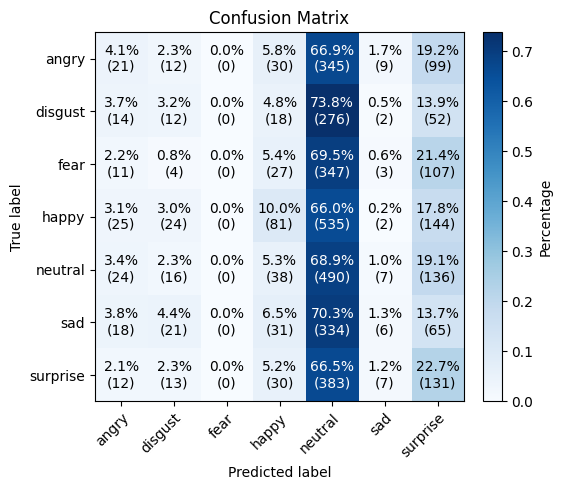

In [20]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

1122/1122 [==============================] - 4s 4ms/step
              precision    recall  f1-score   support

       angry       0.13      0.05      0.08      4953
     disgust       0.03      0.04      0.04       547
        fear       0.29      0.00      0.00      5121
       happy       0.38      0.08      0.13      8989
     neutral       0.19      0.85      0.32      6198
         sad       0.16      0.01      0.02      6077
    surprise       0.21      0.20      0.20      4002

    accuracy                           0.20     35887
   macro avg       0.20      0.18      0.11     35887
weighted avg       0.24      0.20      0.13     35887



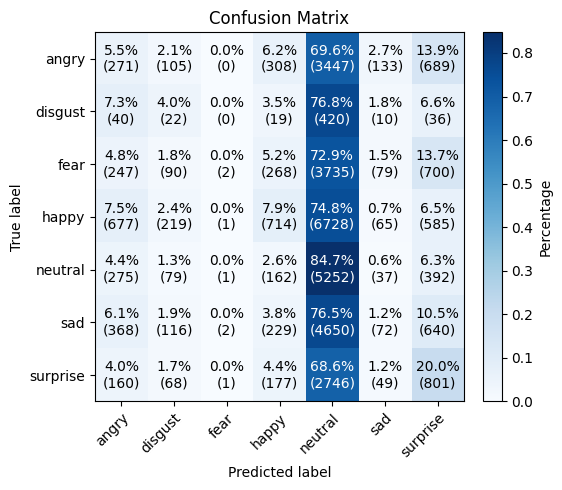

In [21]:
X_test = np.stack(fer["pixels"].values)
y_test = label_encoder.transform(fer['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

29/29 [==============================] - 0s 5ms/step
              precision    recall  f1-score   support

       angry       0.83      0.11      0.20        45
     disgust       0.93      0.24      0.38        59
        fear       1.00      0.04      0.08        25
       happy       0.98      0.67      0.79        69
     neutral       0.78      1.00      0.88       593
         sad       0.67      0.07      0.13        28
    surprise       0.96      0.89      0.93        83

    accuracy                           0.81       902
   macro avg       0.88      0.43      0.48       902
weighted avg       0.83      0.81      0.76       902



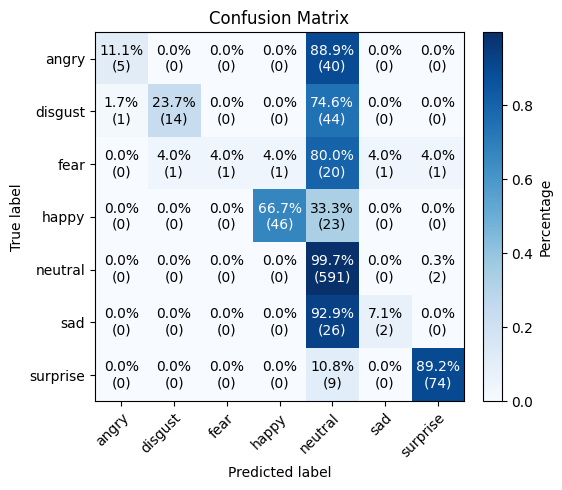

In [22]:
X_test = np.stack(ck["pixels"].values)
y_test = label_encoder.transform(ck['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

96/96 [==============================] - 0s 4ms/step
              precision    recall  f1-score   support

       angry       0.07      0.11      0.09       162
     disgust       0.11      0.04      0.06       160
        fear       1.00      0.01      0.03        74
       happy       0.42      0.03      0.05      1185
     neutral       0.24      0.91      0.38       680
         sad       0.35      0.01      0.03       478
    surprise       0.19      0.05      0.08       329

    accuracy                           0.23      3068
   macro avg       0.34      0.17      0.10      3068
weighted avg       0.33      0.23      0.13      3068



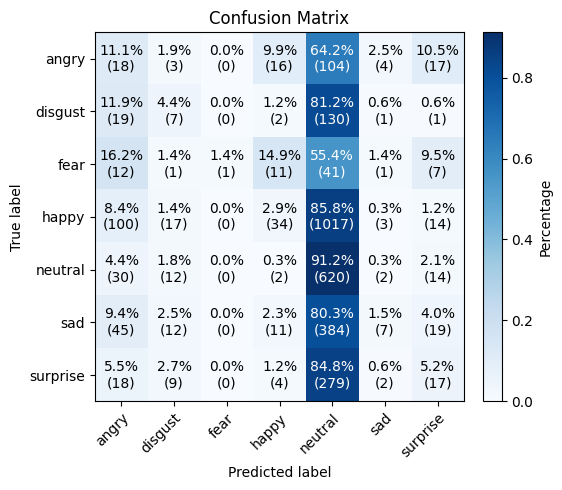

In [23]:
X_test = np.stack(raf["pixels"].values)
y_test = label_encoder.transform(raf['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)